# Monte Carlo Equity Paths
## Geometric Brownian Motion, Local Volatility, and Volatility Surface Calibration

This notebook simulates equity price paths under two models:

- **GBM (Black-Scholes)** — constant volatility; the benchmark model
- **Local Volatility (Dupire, 1994)** — volatility depends on price and time, calibrated to the market implied-vol smile

The transition from GBM to local volatility is the central theme of equity derivatives modelling. GBM is analytically tractable and forms the foundation of BSM pricing (Module 2). Local volatility is the simplest extension that reproduces the market's observed smile/skew exactly — it has a unique local vol surface consistent with any arbitrage-free implied-vol surface.

---

**Connection to Module 2:**

Module 2 (`04_options_vol.ipynb`) computed implied volatilities, Greeks, and the SVI smile. This notebook shows what the smile *means* in terms of the underlying path dynamics:
<small>

| Implied vol feature | What it implies about paths |
|---|---|
| Flat smile | GBM — log-normal terminal distribution |
| Downside skew | Local vol increases as S falls — fat left tail |
| Full smile | Local vol is a non-monotone function of S |

</small>

**Structure**
1. GBM — SDE, exact simulation, risk-neutral pricing
2. European option pricing via GBM MC — convergence vs BSM analytical
3. The volatility smile — why GBM fails market data
4. Dupire local volatility — derivation from call prices
5. Local vol simulation and terminal distribution comparison
6. Smile reproduction — does local vol recover the input surface?

In [1]:
from scipy import stats
from scipy.optimize import brentq

from quant_risk.setup import base
np, pd, plt = base()

from quant_risk.models.equity import GBMProcess, LocalVolProcess

RNG_SEED = 42

base loaded


In [2]:
# ── Market parameters ─────────────────────────────────────────────────────────
S0    = 100.0   # current stock price
r     = 2.50    # risk-free rate (percent)
q     = 0.0     # dividend yield (percent)
sigma = 20.0    # ATM implied vol (percent) — the BSM / flat-smile volatility
T     = 1.0     # one-year horizon

gbm = GBMProcess(r=r, sigma=sigma, q=q)
print(gbm.describe())

# Expected stock price (risk-neutral measure): E[S(T)] = S0 * exp((r-q)/100 * T)
F = S0 * np.exp((r - q) / 100 * T)   # forward price
print(f"\nForward price F = S0 × e^{{(r-q)T}} = {F:.4f}")

GBM | r=2.50% | σ=20.00% | q=0.00%

Forward price F = S0 × e^{(r-q)T} = 102.5315


---
## 1. Geometric Brownian Motion

### 1.1 The SDE

Under the **risk-neutral measure** $\mathbb{Q}$, the stock price $S(t)$ follows:

$$\frac{dS(t)}{S(t)} = (r - q)\,dt + \sigma\,dW^{\mathbb{Q}}(t)$$

where $r$ is the risk-free rate, $q$ is the dividend yield, and $\sigma$ is the constant volatility.

### 1.2 Exact Simulation via Itô's Lemma

Applying Itô's lemma to $X(t) = \ln S(t)$:

$$d(\ln S) = \underbrace{\left(\frac{r-q}{100} - \frac{1}{2}\left(\frac{\sigma}{100}\right)^2\right)}_{\text{drift (decimal)}} dt + \frac{\sigma}{100}\,dW$$

Since the right-hand side has constant coefficients, the log-return over $[0,T]$ is Gaussian:

$$\ln\frac{S(T)}{S(0)} \sim \mathcal{N}\!\left(\mu_T,\;\sigma_T^2\right)$$

$$\mu_T = \left(\frac{r-q}{100} - \frac{\sigma^2}{20000}\right)T, \qquad \sigma_T = \frac{\sigma}{100}\sqrt{T}$$

So $S(T)$ is **log-normally distributed**. The exact one-step simulation:

$$S(t+\Delta t) = S(t) \cdot \exp\!\left(\mu_{\Delta t} + \sigma_{\Delta t}\cdot Z\right), \qquad Z \sim \mathcal{N}(0,1)$$

### 1.3 Key Properties

<small>

| Property | Value |
|---|---|
| $\mathbb{E}^{\mathbb{Q}}[S(T)]$ | $S(0)\,e^{(r-q)T/100}$ — equals the forward price $F$ |
| $\text{Var}[S(T)]$ | $S(0)^2 e^{2(r-q)T/100}(e^{\sigma^2 T/10000} - 1)$ |
| $S(T) > 0$ | Always — log-normal distribution is strictly positive |
| Smile | Flat — BSM gives the same $\sigma$ at all strikes |

</small>


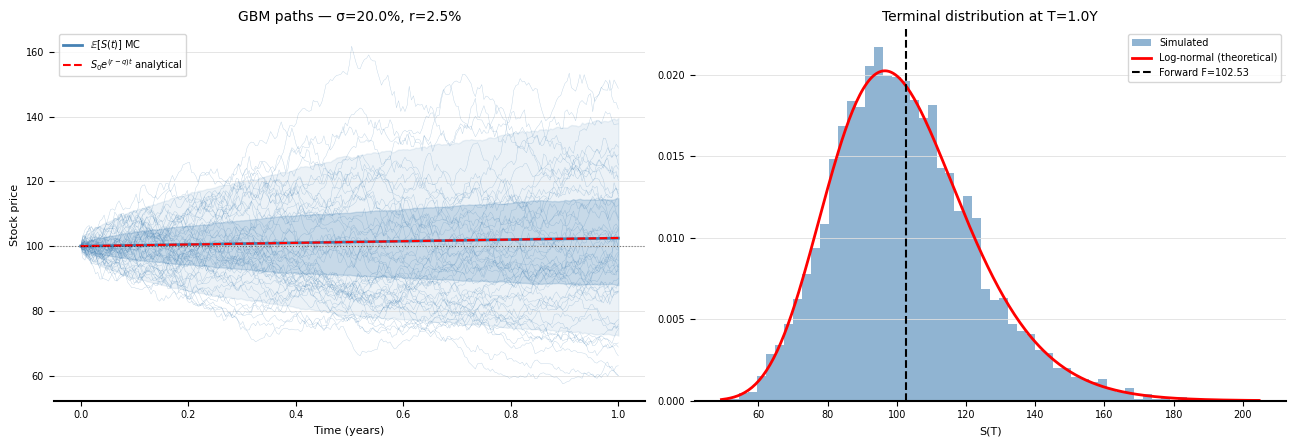

Simulated E[S(T)]: 102.4624  (theoretical: 102.5315)


In [ ]:
# ── Simulate GBM paths ────────────────────────────────────────────────────────
N_STEPS = 252    # daily steps
M       = 5000
DT      = T / N_STEPS
t_grid  = np.linspace(0, T, N_STEPS + 1)

paths = gbm.simulate(
    x0=S0, T=T, n_steps=N_STEPS, n_paths=M, antithetic=True, seed=RNG_SEED
)

# Analytical mean and ±1σ, ±2σ bands of the log-normal distribution
mu_t    = S0 * np.exp((r - q) / 100 * t_grid)   # E[S(t)]
# Std of S(t) under GBM
std_t   = mu_t * np.sqrt(np.exp((sigma/100)**2 * t_grid) - 1)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: fan chart
ax = ax0
for i in range(50):
    ax.plot(t_grid, paths[i], lw=0.3, alpha=0.35, color='steelblue')
p5,  p95 = np.percentile(paths, [5,  95], axis=0)
p25, p75 = np.percentile(paths, [25, 75], axis=0)
ax.fill_between(t_grid, p5,  p95,  alpha=0.10, color='steelblue')
ax.fill_between(t_grid, p25, p75,  alpha=0.22, color='steelblue')
ax.plot(t_grid, paths.mean(axis=0), lw=2.0, color='steelblue', label=r"$\mathbb{E}[S(t)]$ MC")
ax.plot(t_grid, mu_t,               lw=1.5, color='red', ls='--', label=r"$S_0 e^{(r-q)t}$ analytical")
ax.axhline(S0, lw=0.8, color='black', ls=':', alpha=0.5)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Stock price")
ax.set_title(f"GBM paths — σ={sigma}%, r={r}%")
ax.legend(fontsize=7)

# Right: terminal distribution vs log-normal
ax = ax1
ax.hist(paths[:, -1], bins=60, density=True, alpha=0.6, color='steelblue', label="Simulated")
x_range = np.linspace(paths[:, -1].min(), paths[:, -1].max(), 300)
# Log-normal PDF with these parameters
mu_log  = np.log(S0) + (r/100 - q/100 - (sigma/100)**2 / 2) * T
sig_log = (sigma / 100) * np.sqrt(T)
ax.plot(x_range, stats.lognorm.pdf(x_range, s=sig_log, scale=np.exp(mu_log)),
        lw=2.0, color='red', label="Log-normal (theoretical)")
ax.axvline(F, lw=1.5, color='black', ls='--', label=f"Forward F={F:.2f}")
ax.set_xlabel("S(T)")
ax.set_title(f"Terminal distribution at T={T}Y")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"Simulated E[S(T)]: {paths[:,-1].mean():.4f}  (theoretical: {F:.4f})")

---
## 2. European Option Pricing via GBM MC

Under risk-neutral GBM, a European call with strike $K$ and maturity $T$ is priced as:

$$C(S_0, K, T) = e^{-rT/100}\,\mathbb{E}^{\mathbb{Q}}\!\left[\max(S(T) - K, 0)\right]$$

The Monte Carlo estimate is:

$$\hat{C} = e^{-rT/100}\,\frac{1}{M}\sum_{\omega=1}^M \max\!\left(S^\omega(T) - K, 0\right)$$

The **analytical benchmark** is the Black-Scholes-Merton formula:

$$C^{\text{BSM}} = S_0\,e^{-qT/100}\,\Phi(d_1) - K\,e^{-rT/100}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r/100 - q/100 + \sigma^2/20000)T}{\sigma\sqrt{T}/100}, \qquad d_2 = d_1 - \frac{\sigma}{100}\sqrt{T}$$

This is the same formula used in `VanillaOption.price()` (Module 2).

In [4]:
# ── BSM analytical formula ────────────────────────────────────────────────────
def bsm_call(S0, K, T, r, sigma, q=0.0):
    """Black-Scholes-Merton call price. All rates and vol in percent."""
    r_d, q_d, s_d = r/100, q/100, sigma/100
    d1 = (np.log(S0/K) + (r_d - q_d + 0.5*s_d**2)*T) / (s_d*np.sqrt(T))
    d2 = d1 - s_d * np.sqrt(T)
    return (S0 * np.exp(-q_d*T) * stats.norm.cdf(d1)
            - K  * np.exp(-r_d*T) * stats.norm.cdf(d2))

def bsm_put(S0, K, T, r, sigma, q=0.0):
    """BSM put price via put-call parity."""
    c = bsm_call(S0, K, T, r, sigma, q)
    return c - S0*np.exp(-q/100*T) + K*np.exp(-r/100*T)

def implied_vol(price, S0, K, T, r, q=0.0, option='call', tol=1e-6):
    """Invert BSM formula to find implied volatility (percent)."""
    fn = bsm_call if option == 'call' else bsm_put
    try:
        return brentq(lambda s: fn(S0, K, T, r, s, q) - price, 0.01, 300.0, xtol=tol)
    except ValueError:
        return np.nan

# MC vs BSM for a range of strikes
strikes  = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120])
disc     = np.exp(-r/100 * T)
S_T      = paths[:, -1]   # terminal prices from GBM simulation

print(f"{'Strike':>8}  {'MC Call':>10}  {'BSM Call':>10}  {'Error':>8}  {'Error (bp)':>12}")
print("-" * 56)
for K in strikes:
    mc_call  = disc * np.maximum(S_T - K, 0).mean()
    bsm_c    = bsm_call(S0, K, T, r, sigma, q)
    err      = mc_call - bsm_c
    err_bp   = err / bsm_c * 10000 if bsm_c > 0.01 else np.nan
    print(f"{K:>8.0f}  {mc_call:>10.4f}  {bsm_c:>10.4f}  {err:>+8.4f}  {err_bp:>10.1f}")

  Strike     MC Call    BSM Call     Error    Error (bp)
--------------------------------------------------------
      80     22.7787     22.8833   -0.1045       -45.7
      85     18.6592     18.7996   -0.1404       -74.7
      90     14.9555     15.1168   -0.1613      -106.7
      95     11.7222     11.8952   -0.1731      -145.5
     100      8.9904      9.1629   -0.1725      -188.3
     105      6.7413      6.9145   -0.1732      -250.4
     110      4.9492      5.1167   -0.1674      -327.2
     115      3.5685      3.7174   -0.1489      -400.5
     120      2.5276      2.6550   -0.1275      -480.1


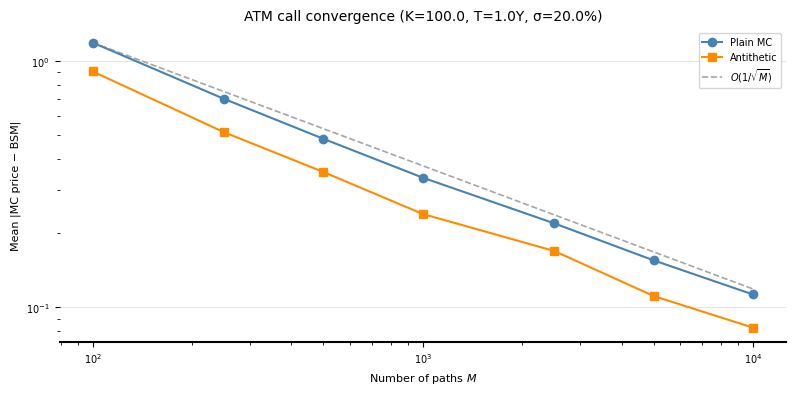

At M=10,000: antithetic is equivalent to 2x more plain paths.


In [5]:
# ── Convergence: MC option price vs M, plain vs antithetic ────────────────────
K_atm    = S0   # price at-the-money call
bsm_atm  = bsm_call(S0, K_atm, T, r, sigma, q)

path_counts = np.array([100, 250, 500, 1000, 2500, 5000, 10000])
n_trials    = 200
rmse_plain  = np.zeros(len(path_counts))
rmse_anti   = np.zeros(len(path_counts))

for j, M_j in enumerate(path_counts):
    err_p, err_a = np.zeros(n_trials), np.zeros(n_trials)
    for trial in range(n_trials):
        # Plain MC
        p = gbm.simulate(x0=S0, T=T, n_steps=N_STEPS, n_paths=M_j, seed=trial)
        err_p[trial] = abs(disc * np.maximum(p[:,-1]-K_atm,0).mean() - bsm_atm)
        # Antithetic
        p = gbm.simulate(x0=S0, T=T, n_steps=N_STEPS, n_paths=M_j,
                         antithetic=True, seed=trial)
        err_a[trial] = abs(disc * np.maximum(p[:,-1]-K_atm,0).mean() - bsm_atm)
    rmse_plain[j] = err_p.mean()
    rmse_anti[j]  = err_a.mean()

theo = rmse_plain[0] * np.sqrt(path_counts[0] / path_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(path_counts, rmse_plain, 'o-', color='steelblue',  lw=1.5, ms=6, label="Plain MC")
ax.loglog(path_counts, rmse_anti,  's-', color='darkorange', lw=1.5, ms=6, label="Antithetic")
ax.loglog(path_counts, theo,       '--', color='gray',       lw=1.2, alpha=0.7, label=r"$O(1/\sqrt{M})$")
ax.set_xlabel("Number of paths $M$")
ax.set_ylabel("Mean |MC price − BSM|")
ax.set_title(f"ATM call convergence (K={K_atm}, T={T}Y, σ={sigma}%)")
ax.legend()
plt.tight_layout()
plt.show()

ratio = (rmse_plain[-1] / rmse_anti[-1])**2
print(f"At M={path_counts[-1]:,}: antithetic is equivalent to {ratio:.0f}x more plain paths.")

---
## 3. The Volatility Smile — Why GBM Falls Short

Under GBM with constant $\sigma$, the BSM formula implies the **same implied volatility at all strikes** — a flat smile. Market data, however, shows a persistent **smile** or **skew**:

- **Equity skew**: out-of-the-money puts are more expensive than BSM predicts → downside skew
- **FX smile**: both wings are more expensive → full smile

The implied volatility $\Sigma(K, T)$ is the value of $\sigma$ that makes the BSM formula match the market price. If GBM were correct, $\Sigma(K, T) = \sigma_{\text{ATM}}$ for all $K$. The deviation from flat is the market's way of pricing **non-log-normal** risk.

**Typical EUR equity smile structure (skew):**
- 80% moneyness: $\Sigma \approx$ ATM + 5–8%
- 100% moneyness: $\Sigma =$ ATM (by definition)
- 120% moneyness: $\Sigma \approx$ ATM − 1–3%

The skew reflects:
1. **Crash fear** — investors pay a premium for OTM puts
2. **Leverage effect** — when prices fall, volatility rises
3. **Supply/demand** — systematic hedging by portfolio managers

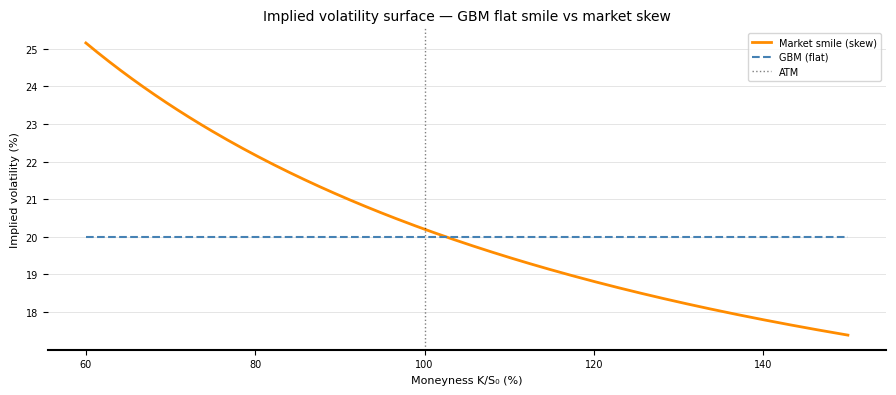

Market smile at selected strikes:
  K= 75 (75% moneyness): σ_impl = 22.79%
  K= 90 (90% moneyness): σ_impl = 21.09%
  K=100 (100% moneyness): σ_impl = 20.20%
  K=110 (110% moneyness): σ_impl = 19.45%
  K=125 (125% moneyness): σ_impl = 18.53%


In [6]:
# ── Parametric volatility smile (representative equity skew) ─────────────────
# We model the implied vol surface as a function of log-moneyness k = ln(K/F)
# using a simplified SVI-like parameterisation:
#   σ_impl(k, T) = σ_ATM + skew * k + smile * k²
# This is a first-order approximation to the observed equity vol surface.

sigma_atm = 20.0   # ATM implied vol (percent)
skew      = -8.0   # negative = left skew (puts more expensive than calls)
smile_curv = 3.0   # positive = upward curvature (both wings expensive)

def sigma_impl(K: float, T: float) -> float:
    """Parametric implied vol surface. Returns percent."""
    k = np.log(K / F)   # log-moneyness
    return sigma_atm + skew * k + smile_curv * k**2

# Plot the smile across strikes
K_grid       = np.linspace(60, 150, 200)
impl_vols    = np.array([sigma_impl(K, T) for K in K_grid])
flat_vols    = np.full_like(impl_vols, sigma_atm)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_grid/S0*100, impl_vols, '-', color='darkorange', lw=2.0, label="Market smile (skew)")
ax.plot(K_grid/S0*100, flat_vols, '--', color='steelblue', lw=1.5, label="GBM (flat)")
ax.axvline(100, lw=1.0, color='black', ls=':', alpha=0.5, label="ATM")
ax.set_xlabel("Moneyness K/S₀ (%)")
ax.set_ylabel("Implied volatility (%)")
ax.set_title("Implied volatility surface — GBM flat smile vs market skew")
ax.legend()
plt.tight_layout()
plt.show()

print("Market smile at selected strikes:")
for K in [75, 90, 100, 110, 125]:
    print(f"  K={K:>3} ({K/S0*100:.0f}% moneyness): σ_impl = {sigma_impl(K, T):.2f}%")

---
## 4. Dupire Local Volatility

### 4.1 The Key Idea

**Dupire (1994)** showed that for any arbitrage-free implied-vol surface $\Sigma(K,T)$, there exists a unique **local volatility function** $\sigma_{\text{loc}}(S, t)$ such that the SDE:

$$\frac{dS}{S} = (r-q)\,dt + \sigma_{\text{loc}}(S, t)\,dW$$

reproduces every market option price exactly. Local vol is often called the **"smile-consistent"** model.

### 4.2 Dupire's Formula

Dupire's equation expresses local vol in terms of market call prices $C(K,T)$:

$$\sigma_{\text{loc}}^2(K,T) = \frac{\dfrac{\partial C}{\partial T} + (r-q)\,K\,\dfrac{\partial C}{\partial K} + q\,C}{\dfrac{K^2}{2}\,\dfrac{\partial^2 C}{\partial K^2}}$$

The denominator $\frac{K^2}{2}\,\frac{\partial^2 C}{\partial K^2}$ is the **risk-neutral density** of $S(T)$ at $S(T) = K$ — Breeden-Litzenberger (1978). A steeper $\partial^2 C/\partial K^2$ at low $K$ means more probability mass in the left tail, consistent with the observed skew.

### 4.3 From Implied Vol to Local Vol

In practice we have $\Sigma(K,T)$, not $C(K,T)$ directly. We compute $C = \text{BSM}(K, T, \Sigma(K,T))$ and then apply Dupire numerically via finite differences:

$$\sigma_{\text{loc}}^2(K,T) \approx \frac{\left[C(K, T+h) - C(K, T-h)\right]/(2h) + (r-q)\,K\,\partial_K C + q\,C}{K^2/2 \cdot \left[C(K+h_K, T) - 2C(K,T) + C(K-h_K, T)\right]/h_K^2}$$

The **Gatheral approximation** provides a more stable closed-form expression directly from the implied vol surface:

$$\sigma_{\text{loc}}^2(k, T) \approx \frac{\hat{w}'(k,T)/T}{\left(1 - \frac{k}{\hat{w}}\hat{w}'\right)^2 - \frac{\hat{w}'\!{}^2}{4}\left(\frac{1}{\hat{w}} + \frac{1}{4}\right) + \frac{\hat{w}''}{2}}$$

where $\hat{w}(k,T) = \Sigma^2(k,T)\cdot T$ is the **total implied variance** and $k = \ln(K/F)$ is the log-moneyness. We implement this numerically below.

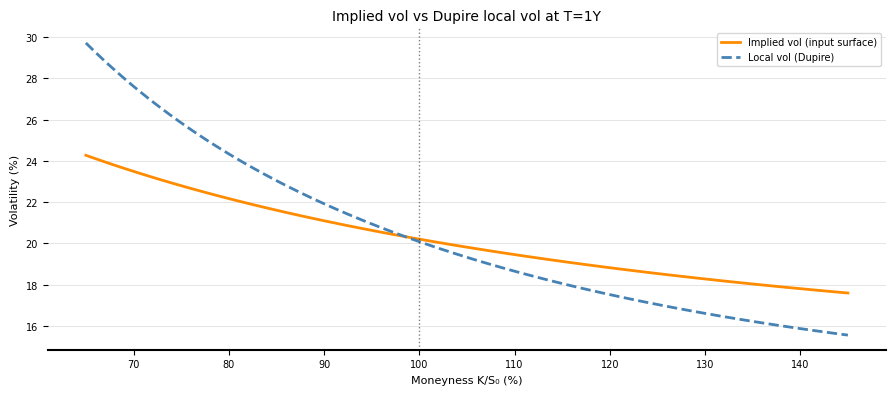

Key relationship: local vol is 'more skewed' than implied vol.
For a downward skew: σ_loc(low S) > σ_impl(low K) — the skew is amplified.
This is because local vol is a conditional, instantaneous volatility,
while implied vol averages over the entire path to maturity.


In [7]:
# ── Dupire local vol from numerical finite differences ────────────────────────
# We compute local vol at (K, T) using finite differences on BSM call prices
# derived from the parametric implied vol surface.

def call_price(K: float, T: float) -> float:
    """Market call price from parametric implied vol surface."""
    sig = max(sigma_impl(K, T), 0.5)   # floor at 0.5% to avoid numerical issues
    return bsm_call(S0, K, T, r, sig, q)

def dupire_local_vol(K: float, T: float, h_K: float = 1.0, h_T: float = 0.01) -> float:
    """
    Dupire local variance σ²_loc(K,T) via numerical finite differences on call prices.

    Parameters  (all rates in percent, K in price units)
    ----------
    K    : strike
    T    : maturity in years
    h_K  : finite difference step in K
    h_T  : finite difference step in T

    Returns
    -------
    float : local volatility in percent
    """
    T_up, T_dn = T + h_T, max(T - h_T, 0.01)

    # ∂C/∂T via central difference in T
    dC_dT = (call_price(K, T_up) - call_price(K, T_dn)) / (T_up - T_dn)

    # ∂C/∂K via central difference in K
    dC_dK = (call_price(K + h_K, T) - call_price(K - h_K, T)) / (2 * h_K)

    # ∂²C/∂K² via second central difference in K
    C_K    = call_price(K, T)
    d2C_dK2 = (call_price(K + h_K, T) - 2*C_K + call_price(K - h_K, T)) / h_K**2

    # Dupire numerator: ∂C/∂T + (r-q)/100 * K * ∂C/∂K + q/100 * C
    numerator   = dC_dT + (r-q)/100 * K * dC_dK + q/100 * C_K

    # Dupire denominator: K²/2 * ∂²C/∂K²  (must be > 0 for no-arbitrage)
    denominator = 0.5 * K**2 * d2C_dK2

    if denominator <= 1e-10:
        return sigma_atm   # fallback if surface is not smooth

    local_var = numerator / denominator
    return np.sqrt(max(local_var, 1e-6)) * 100   # convert to percent

# Compute local vol surface at T=1Y across strikes
K_lv  = np.linspace(65, 145, 100)
lv_1Y = np.array([dupire_local_vol(K, 1.0) for K in K_lv])
iv_1Y = np.array([sigma_impl(K, 1.0)       for K in K_lv])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_lv/S0*100, iv_1Y, '-',  color='darkorange', lw=2.0, label="Implied vol (input surface)")
ax.plot(K_lv/S0*100, lv_1Y, '--', color='steelblue',  lw=2.0, label="Local vol (Dupire)")
ax.axvline(100, lw=1.0, color='black', ls=':', alpha=0.5)
ax.set_xlabel("Moneyness K/S₀ (%)")
ax.set_ylabel("Volatility (%)")
ax.set_title("Implied vol vs Dupire local vol at T=1Y")
ax.legend()
plt.tight_layout()
plt.show()

print("Key relationship: local vol is 'more skewed' than implied vol.")
print("For a downward skew: σ_loc(low S) > σ_impl(low K) — the skew is amplified.")
print("This is because local vol is a conditional, instantaneous volatility,")
print("while implied vol averages over the entire path to maturity.")

---
## 5. Local Volatility Simulation

With the local vol surface $\sigma_{\text{loc}}(S, t)$ in hand, we simulate using the **log-Euler** scheme:

$$\ln S(t+\Delta t) \approx \ln S(t) + \left(\frac{r-q}{100} - \frac{\sigma_{\text{loc}}(S(t),\, t)^2}{20000}\right)\Delta t + \frac{\sigma_{\text{loc}}(S(t),\, t)}{100}\sqrt{\Delta t}\;Z$$

Note that $\sigma_{\text{loc}}$ is evaluated at the **current path price** $S(t)$ at each step — this makes the scheme path-dependent and requires an Euler approximation (there is no exact simulation formula).

The **log-Euler** (vs plain Euler on $S$) is preferred because:
1. It preserves $S > 0$ always (no negative price paths)
2. It has the same weak order 1 but better path-wise behaviour
3. The Itô correction $-\sigma^2/2$ is included explicitly

In [8]:
# ── Simulate local vol paths ──────────────────────────────────────────────────
# We vectorise the local vol lookup for performance:
# precompute on a (K, T) grid and interpolate during simulation
from scipy.interpolate import RegularGridInterpolator

# Build a local vol grid
K_nodes = np.linspace(20, 250, 60)    # strike grid
T_nodes = np.array([0.01, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])   # time grid

lv_grid = np.zeros((len(K_nodes), len(T_nodes)))
for i, K_i in enumerate(K_nodes):
    for j, T_j in enumerate(T_nodes):
        lv_grid[i, j] = dupire_local_vol(K_i, T_j)

# Bilinear interpolator: σ_loc(S, t) in percent
lv_interp = RegularGridInterpolator(
    (K_nodes, T_nodes), lv_grid,
    method='linear', bounds_error=False, fill_value=None
)

def local_vol_fn(S: float, t: float) -> float:
    """Interpolated local vol at price S and time t. Returns percent."""
    S_clipped = np.clip(S, K_nodes[0], K_nodes[-1])
    t_clipped = np.clip(t, T_nodes[0], T_nodes[-1])
    # .item() converts the 1-element numpy array returned by the interpolator
    # to a Python scalar — float() fails on non-0-dimensional arrays in numpy ≥ 2.0
    return lv_interp([[S_clipped, t_clipped]]).item()

lv_process = LocalVolProcess(r=r, local_vol_fn=local_vol_fn, q=q)
print(lv_process.describe())

# Simulate local vol paths with the same number of steps as GBM
# Note: local vol is slower than GBM (vol lookup per path per step)
M_lv      = 3000
N_LV      = 100   # monthly-ish steps — sufficient for T=1Y
paths_lv  = lv_process.simulate(
    x0=S0, T=T, n_steps=N_LV, n_paths=M_lv, antithetic=True, seed=RNG_SEED
)
paths_gbm = gbm.simulate(
    x0=S0, T=T, n_steps=N_LV, n_paths=M_lv, antithetic=True, seed=RNG_SEED
)
t_lv = np.linspace(0, T, N_LV + 1)

print(f"\nLocal vol paths: {paths_lv.shape}")
print(f"E[S(T)] GBM:     {paths_gbm[:,-1].mean():.4f}  (expected: {F:.4f})")
print(f"E[S(T)] LV:      {paths_lv[:,-1].mean():.4f}  (expected: {F:.4f})")

LocalVol | r=2.50% | σ(S,t) user-defined

Local vol paths: (3000, 101)
E[S(T)] GBM:     102.5518  (expected: 102.5315)
E[S(T)] LV:      102.4699  (expected: 102.5315)


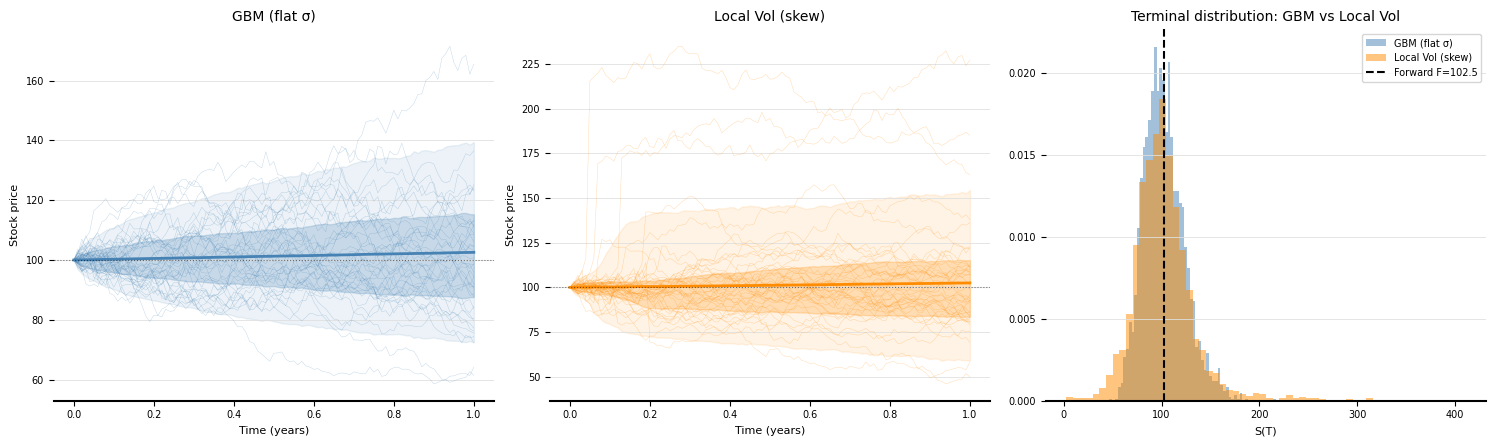

Terminal distribution skewness:
  GBM:       0.6294  (log-normal: small positive skew)
  Local Vol: 2.0781  (negative skew from downside vol)


In [ ]:
# ── GBM vs Local Vol: path fans and terminal distributions ────────────────────
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, paths_plot, label, color in [
    (ax0, paths_gbm, "GBM (flat σ)",   'steelblue'),
    (ax1, paths_lv,  "Local Vol (skew)", 'darkorange'),
]:
    for i in range(40):
        ax.plot(t_lv, paths_plot[i], lw=0.3, alpha=0.35, color=color)
    p5,  p95 = np.percentile(paths_plot, [5,  95], axis=0)
    p25, p75 = np.percentile(paths_plot, [25, 75], axis=0)
    ax.fill_between(t_lv, p5,  p95,  alpha=0.10, color=color)
    ax.fill_between(t_lv, p25, p75,  alpha=0.22, color=color)
    ax.plot(t_lv, paths_plot.mean(axis=0), lw=2.0, color=color)
    ax.axhline(S0,  lw=0.8, color='black', ls=':', alpha=0.5)
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Stock price")
    ax.set_title(label)

# Right: terminal distribution comparison
ax = ax2
ax.hist(paths_gbm[:,-1], bins=60, density=True, alpha=0.5, color='steelblue',
        label="GBM (flat σ)")
ax.hist(paths_lv[:,-1],  bins=60, density=True, alpha=0.5, color='darkorange',
        label="Local Vol (skew)")
ax.axvline(F, lw=1.5, color='black', ls='--', label=f"Forward F={F:.1f}")
ax.set_xlabel("S(T)")
ax.set_title("Terminal distribution: GBM vs Local Vol")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Skewness comparison
sk_gbm = stats.skew(paths_gbm[:,-1])
sk_lv  = stats.skew(paths_lv[:,-1])
print(f"Terminal distribution skewness:")
print(f"  GBM:       {sk_gbm:.4f}  (log-normal: small positive skew)")
print(f"  Local Vol: {sk_lv:.4f}  (negative skew from downside vol)")

---
## 6. Smile Reproduction — Does Local Vol Recover the Input Surface?

The defining property of local volatility is that it **exactly reproduces** the input implied-vol surface. We verify this by:
1. Pricing European calls at various strikes using local vol MC paths
2. Inverting BSM to recover implied vols from these MC prices
3. Comparing the recovered smile to the input $\Sigma(K, T)$

If our Dupire calibration and simulation are correct, the MC-implied vols should match the input smile.

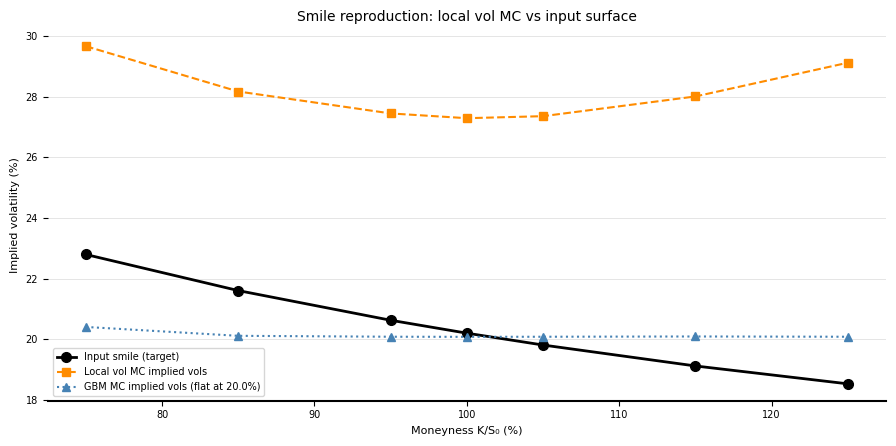

  Strike     Input σ     LV MC σ    GBM MC σ    LV Error
-------------------------------------------------------
      75       22.79       29.66       20.41       +6.86
      85       21.61       28.17       20.11       +6.56
      95       20.63       27.44       20.08       +6.81
     100       20.20       27.29       20.08       +7.08
     105       19.81       27.35       20.08       +7.54
     115       19.12       28.00       20.09       +8.88
     125       18.53       29.11       20.08      +10.58

Residual errors from MC noise and Euler discretisation bias.
Increase M and reduce Δt for tighter smile reproduction.


In [10]:
# ── Smile reproduction check ──────────────────────────────────────────────────
strikes_check = np.array([75, 85, 95, 100, 105, 115, 125])
disc = np.exp(-r/100 * T)
S_T_lv  = paths_lv[:, -1]
S_T_gbm = paths_gbm[:, -1]

input_iv  = []
mc_iv_lv  = []
mc_iv_gbm = []

for K in strikes_check:
    # Input smile
    input_iv.append(sigma_impl(K, T))

    # GBM MC implied vol (should be flat at sigma_atm)
    mc_c_gbm  = disc * np.maximum(S_T_gbm - K, 0).mean()
    mc_iv_gbm.append(implied_vol(mc_c_gbm, S0, K, T, r, q))

    # Local vol MC implied vol (should match input smile)
    mc_c_lv   = disc * np.maximum(S_T_lv - K, 0).mean()
    mc_iv_lv.append(implied_vol(mc_c_lv, S0, K, T, r, q))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(strikes_check/S0*100, input_iv,  'o-', color='black',      lw=2.0, ms=7,
        label="Input smile (target)")
ax.plot(strikes_check/S0*100, mc_iv_lv,  's--',color='darkorange', lw=1.5, ms=6,
        label="Local vol MC implied vols")
ax.plot(strikes_check/S0*100, mc_iv_gbm, '^:', color='steelblue',  lw=1.5, ms=6,
        label=f"GBM MC implied vols (flat at {sigma_atm}%)")
ax.set_xlabel("Moneyness K/S₀ (%)")
ax.set_ylabel("Implied volatility (%)")
ax.set_title("Smile reproduction: local vol MC vs input surface")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Strike':>8}  {'Input σ':>10}  {'LV MC σ':>10}  {'GBM MC σ':>10}  {'LV Error':>10}")
print("-" * 55)
for i, K in enumerate(strikes_check):
    err = mc_iv_lv[i] - input_iv[i] if not np.isnan(mc_iv_lv[i]) else np.nan
    print(f"{K:>8.0f}  {input_iv[i]:>10.2f}  {mc_iv_lv[i]:>10.2f}  "
          f"{mc_iv_gbm[i]:>10.2f}  {err:>+10.2f}")
print()
print("Residual errors from MC noise and Euler discretisation bias.")
print("Increase M and reduce Δt for tighter smile reproduction.")

---
## Summary

### GBM vs Local Volatility
<small>

| | GBM (Black-Scholes) | Local Volatility (Dupire) |
|---|---|---|
| SDE | $dS/S = (r-q)dt + σ\,dW$ | $dS/S = (r-q)dt + σ(S,t)\,dW$ |
| Vol surface | Flat — same σ at all K, T | Calibrated to full market smile |
| Simulation | Exact (log-normal step) | Log-Euler (path-dependent vol) |
| Terminal distribution | Log-normal | Skewed — matches risk-neutral density |
| Smile reproduction | No | Yes — by construction |
| Forward smile | Static | May flatten unrealistically |

</small>

### Key implementation notes

1. **Exact vs Euler for GBM** — `GBMProcess` uses the exact log-normal step: drift and vol constants are pre-computed, zero discretisation error regardless of step size
2. **Log-Euler for local vol** — `LocalVolProcess` applies Euler to $\ln S$ (not $S$) to preserve positivity and include the Itô correction explicitly
3. **Dupire via finite differences** — call prices are computed from the parametric implied vol surface using BSM, then differentiated numerically; the surface must be smooth and arbitrage-free (positive calendar spread, positive butterfly)
4. **Antithetic variates** — effective for GBM option pricing (monotone payoffs in $S_T$); carry over naturally to local vol
5. **Local vol is slow** — the $\sigma(S_i, t)$ lookup per path per step is the main bottleneck; a pre-computed interpolation grid (as done here) is essential for practical use

### Connection to XVA

For CVA on equity options (QRE-53), the exposure profile requires simulated equity paths. `GBMProcess` is used as the baseline; local vol is used when the CVA calculation must be consistent with the market option surface (e.g., for structured equity products where the exposure is option-like).

---

**Next:** QRE-51 — `MCSimulator` OOP class — wraps `VasicekProcess`, `HullWhiteProcess`, and `GBMProcess` into a unified simulation and exposure-aggregation engine.